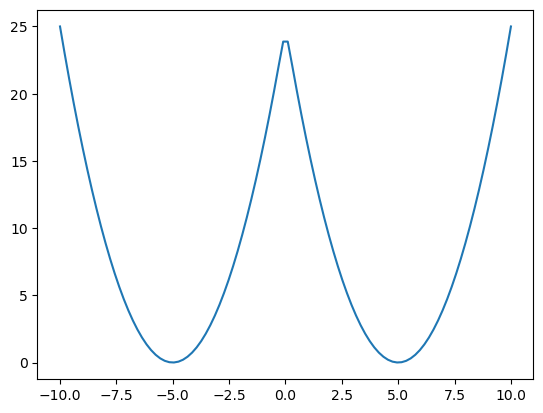

In [2]:
import numpy as np
import matplotlib.pyplot as plt

mu1    = -5
sigma1 = 1
mu2    = 5
sigma2 = 1

x = np.linspace(-10,10,100)

A = np.exp(-np.square(x-mu1))
B = np.exp(-np.square(x-mu2))

y = -np.log(A + B)

plt.plot(x,y)

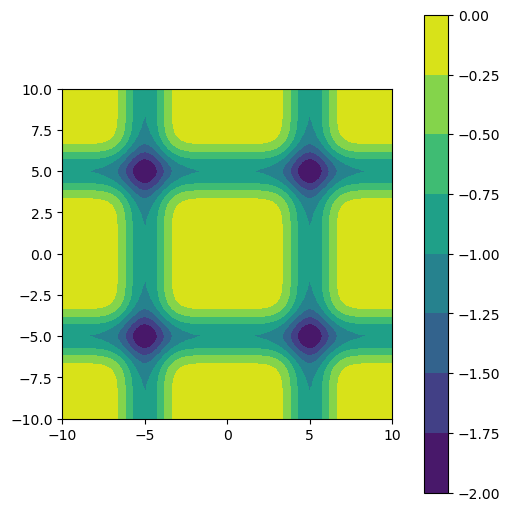

In [3]:

x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

p1 = (-5,-5)
p2 = (5,5)

E = np.zeros((100,100))
for i in range(100):
    for j in range(100):
        r_x_1 = np.abs(x[i]-p1[0])
        r_x_2 = np.abs(x[i]-p2[0])

        r_y_1 = np.abs(y[j]-p1[1])
        r_y_2 = np.abs(y[j]-p1[1])

        Ex = -(np.exp(-np.square(x[i]-p2[0])/(2*sigma1**2)) + np.exp(-np.square(x[i]-p1[0])/(2*sigma2**2)))
        Ey = -(np.exp(-np.square(y[j]-p2[1])/(2*sigma1**2)) + np.exp(-np.square(y[j]-p1[1])/(2*sigma2**2)))

        E[i,j] = Ex + Ey

X,Y = np.meshgrid(np.linspace(-10,10,100),np.linspace(-10,10,100))
fig, axs = plt.subplots(1,1,figsize=(5,5),layout='constrained')
c = axs.contourf(X,Y,E)
axs.set_aspect('equal')
fig.colorbar(c)

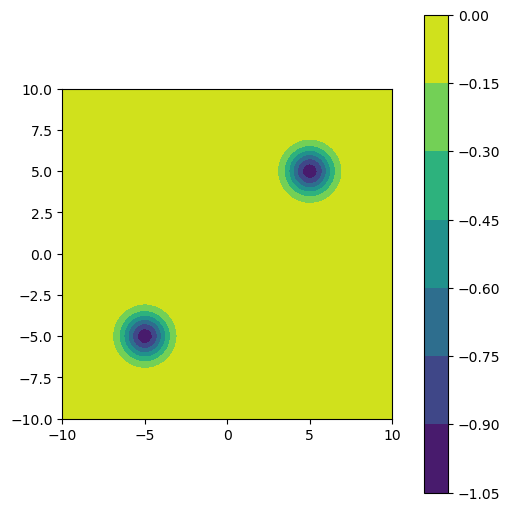

In [4]:
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

p1 = np.array([-5,-5])
p2 = np.array([5,5])

X,Y = np.meshgrid(np.linspace(-10,10,100),np.linspace(-10,10,100))
E = np.zeros((100,100))
for i in range(100):
    for j in range(100):
        r1 = np.linalg.norm(np.array([x[i],y[j]])-p1)
        r2 = np.linalg.norm(np.array([x[i],y[j]])-p2)

        E[i,j] = -(np.exp(-np.square(r1)/(2*sigma1**2)) + np.exp(-np.square(r2)/(2*sigma2**2)))

fig, axs = plt.subplots(1,1,figsize=(5,5),layout='constrained')
c = axs.contourf(X,Y,E)
axs.set_aspect('equal')
fig.colorbar(c)

In [5]:
from openmmnapshift.utils import read_chemical_shifts

ATOM_TYPES = ['CA','CB','C','H','HA','N']

RC_CS_data = read_chemical_shifts("Data/1DJF/RC_CS.txt")
RC_CS = np.nan*np.ones((len(RC_CS_data.keys()),6))
for residx, residue_CS in enumerate(RC_CS_data.values()):
    for atom_idx, atom in enumerate(ATOM_TYPES):
        RC_CS[residx][atom_idx] = residue_CS[1][atom]

CS_data = read_chemical_shifts("Data/1DJF/CS.txt")
CS = np.nan*np.ones((len(CS_data.keys()),6))
for residx, residue_CS in enumerate(CS_data.values()):
    for atom_idx, atom in enumerate(ATOM_TYPES):
        CS[residx][atom_idx] = residue_CS[1][atom]

In [6]:
diff = (RC_CS-RC_CS)-(CS-RC_CS)
diff = np.where(np.isnan(diff),0,diff)
np.linalg.norm(diff)

13.31960310970263

In [80]:
p1 = RC_CS-RC_CS
p2 = CS-RC_CS

p1=p2

/tmp/ipykernel_11754/250454232.py:30: RuntimeWarning: divide by zero encountered in log
  y = -np.log(A + B)


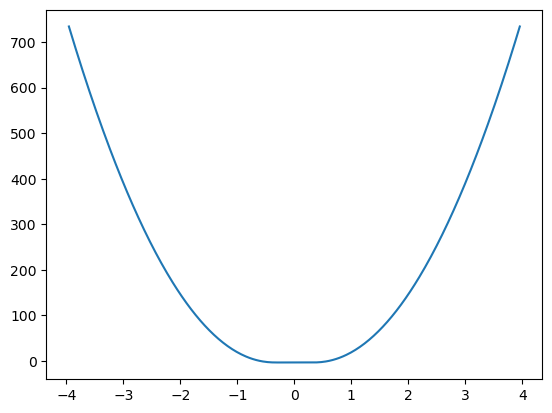

In [83]:
K1 = 25
K2 = 0
sigma1 = 3
sigma2 = 3

ps = np.linspace(-10,10,1000)
ys = []

model_errors = [ 1.286, 1.314,  1.187, 0.425, 0.284, 2.566 ] 

for p in ps:
    x = (1-p)*p1 + p*p2
    x = p1 + p1*p

    r1 = np.abs(x-p1)
    r1 = np.where(np.isnan(r1), 0, r1)
    r1 = np.where(np.abs(r1)<model_errors,0,r1-model_errors) #np.abs(r1)-model_errors
    r1 = np.sqrt(np.sum(np.square(r1)))

    r2 = np.abs(x-p2)
    r2 = np.where(np.isnan(r2), 0, r2)
    r2 = np.where(np.abs(r2)<model_errors,0,r2-model_errors) #np.abs(r2)-model_errors
    r2 = np.sqrt(np.sum(np.square(r2)))

    #print(r1)
    #print(r2)

    A = K1*np.exp(-np.square(r1)/sigma1)
    B = K2*np.exp(-np.square(r2)/sigma2)
    y = -np.log(A + B)
    
    ys.append(y)

plt.plot(ps, ys)